# 02 · Docker sandbox for the agent's code execution

The agent's `run_python` tool will run in an **isolated Docker container, one per conversation**:

* the **image** (`aeronet-sandbox`: Python + pinned libraries + the exec server) is built **once**, section 3
* a **container** is started from that static image per `conversation_id` (container name = conversation id); nothing is rebuilt per conversation, only the mounted folders differ
* `--network none`, **2 GB RAM, 2 vCPU**, no root, read-only file system
* storage clipped to *N* GB: the only writable place is `/workspace`; if it goes over *N* GB the container is **killed**, the newest files are deleted back under the cap, and the agent is told why (memory-limit kills and idle stops are reported the same way)
* the parquet from notebook 01 mounted **read-only** at `/data/aeronet.parquet`
* `conversation_data/<conversation_id>/` (in this repo, gitignored) mounted **read-write** at `/workspace` → every plot / parquet the code exports shows up there locally
* a tiny HTTP server inside the container (over a Unix socket, because there is no network) with 4 endpoints:
  `exec` · `state` · `reset` · `env`
* the container **kills itself after 60 min without a request** and Docker removes it (`--rm`)

No docker-compose: compose is for a fixed set of services, here containers come and go per conversation, so plain `docker run` from Python is simpler.

Run this notebook from the `notebooks/` folder.

In [1]:
import time
from pathlib import Path
from IPython.display import Image, display

assert (Path.cwd().parent / "DATA" / "PROCESSED" / "AERONET_AOD_L2_Daily_V3.parquet").exists(), "run notebook 01 first"


## 1 · Dockerfile

Libraries are pinned here, in the image, not in the repo's `requirements.txt` (that file is for the notebooks / harness; this is the sandbox's own environment).

In [2]:
%%writefile ../sandbox/Dockerfile
# Sandbox image for the agent's code execution. Libraries are pinned HERE (not in
# the repo's requirements.txt) because this is the container's own environment.
FROM python:3.13-slim

RUN pip install --no-cache-dir \
    numpy==2.2.2 \
    pandas==2.2.3 \
    pyarrow==24.0.0 \
    matplotlib==3.11.2 \
    seaborn==0.13.2 \
    scipy==1.18.1 \
    statsmodels==0.15.0 \
    ipython==9.17.1

# root fs is mounted read-only at run time -> everything writable lives in /tmp (tmpfs) or /workspace
ENV HOME=/tmp MPLCONFIGDIR=/tmp/mpl MPLBACKEND=Agg PYTHONUNBUFFERED=1

COPY exec_server.py /exec_server.py
WORKDIR /workspace
CMD ["python", "/exec_server.py"]


Overwriting ../sandbox/Dockerfile


## 2 · Exec server (runs inside the container)

One IPython shell kept in memory, so variables persist between `exec` calls of the same conversation. Single-threaded on purpose: one cell at a time.

In [3]:
%%writefile ../sandbox/exec_server.py
"""
Tiny HTTP server (over a Unix socket, so it works with --network none) that runs
Python code in ONE persistent IPython shell. Variables survive between calls.

  POST /exec   {"code": "...", "timeout": 60}  -> stdout, stderr, error, result preview,
                                                  figures saved, new files, namespace diff, elapsed, rss_mb
  GET  /state                                  -> variables (type + shape), files in /workspace, rss_mb
  POST /reset                                  -> clear variables, close figures
  GET  /env                                    -> python + package versions, limits

Two watchdog threads end the process (run the container with --rm and Docker removes it):
  * idle:    no request for IDLE_MINUTES
  * storage: /workspace above WORKSPACE_GB -> newest files deleted until under the cap, then exit
Before exiting they write the reason to /workspace/_killed.txt so the host can tell the agent.
"""
import json, os, signal, socketserver, sys, threading, time
from http.server import BaseHTTPRequestHandler
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.figure

_saved_by_code = set()                                   # ids of figures the cell saved itself (fig.savefig / plt.savefig)
_orig_savefig = matplotlib.figure.Figure.savefig
def _tracked_savefig(self, *a, **k):
    out = _orig_savefig(self, *a, **k)
    _saved_by_code.add(id(self))
    return out
matplotlib.figure.Figure.savefig = _tracked_savefig
import pandas as pd
from IPython.core.interactiveshell import InteractiveShell
from IPython.utils.capture import capture_output
from traitlets.config import Config

WORKSPACE = Path("/workspace")
SOCKET = WORKSPACE / "exec.sock"
KILLED = WORKSPACE / "_killed.txt"
WORKSPACE_CAP = int(float(os.environ.get("WORKSPACE_GB", "1")) * 1e9)   # bytes allowed in /workspace
IDLE_SECONDS = float(os.environ.get("IDLE_MINUTES", "60")) * 60         # exit after this much inactivity
CLIP = 4000                                                             # max chars per text field
last_activity = time.time()

STARTUP = """
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
DATA = "/data/aeronet.parquet"   # AERONET AOD L2 daily table (read-only)
"""

cfg = Config()
cfg.HistoryManager.enabled = False          # no sqlite history file (root fs is read-only)
cfg.InteractiveShell.colors = "nocolor"     # plain-text tracebacks
shell = InteractiveShell.instance(config=cfg)
shell.displayhook.write_output_prompt = lambda: None            # don't echo "Out[n]: ..." into stdout,
shell.displayhook.write_format_data = lambda *a, **k: None      # the last expression comes back as `result`
BASE_NAMES = set()
fig_counter = 0


# ── helpers ──────────────────────────────────────────────────────────────────
def clip(s):
    s = str(s)
    return s if len(s) <= CLIP else s[: CLIP // 2] + f"\n... [{len(s) - CLIP} chars clipped] ...\n" + s[-CLIP // 2:]


def describe(obj):
    try:
        shape = getattr(obj, "shape", None)
        return f"{type(obj).__name__}{tuple(shape)}" if shape is not None else type(obj).__name__
    except Exception:
        return type(obj).__name__


def preview(obj):
    if obj is None:
        return None
    if isinstance(obj, pd.DataFrame):
        return clip(f"DataFrame {obj.shape}\ndtypes:\n{obj.dtypes.to_string()}\n\n"
                    f"head:\n{obj.head().to_string()}\n\ntail:\n{obj.tail().to_string()}")   # to_string: never hide columns with ...
    return clip(repr(obj))


def user_vars():
    return {k: describe(v) for k, v in shell.user_ns.items() if k not in BASE_NAMES and not k.startswith("_")}


def snapshot():
    return {k: (id(v), describe(v)) for k, v in shell.user_ns.items()}


def files():
    return sorted(str(p.relative_to(WORKSPACE)) for p in WORKSPACE.rglob("*") if p.is_file() and p not in (SOCKET, KILLED))


def workspace_bytes():
    return sum(p.stat().st_size for p in WORKSPACE.rglob("*") if p.is_file())


def rss_mb():
    return int(open("/proc/self/statm").read().split()[1]) * os.sysconf("SC_PAGE_SIZE") // 1_000_000


def save_figures(new_files):
    """PNGs the cell wrote itself + auto-saved copies (fig_NNN.png) of figures it left unsaved; then close all."""
    global fig_counter
    saved = [f for f in new_files if f.lower().endswith(".png")]
    for n in plt.get_fignums():
        fig = plt.figure(n)
        if id(fig) in _saved_by_code:
            continue
        fig_counter += 1
        path = WORKSPACE / f"fig_{fig_counter:03d}.png"
        fig.savefig(path, dpi=100, bbox_inches="tight")
        saved.append(path.name)
    plt.close("all")
    _saved_by_code.clear()
    return saved


def _timeout(signum, frame):
    raise TimeoutError("cell exceeded its timeout")

signal.signal(signal.SIGALRM, _timeout)
signal.signal(signal.SIGTERM, lambda *a: sys.exit(0))   # so `docker stop` is instant


def die(reason):
    KILLED.write_text(reason)
    print(reason, flush=True)
    os._exit(3)


def idle_watchdog():
    while True:
        time.sleep(5)
        if time.time() - last_activity > IDLE_SECONDS:
            die(f"idle-stopped after {IDLE_SECONDS/60:g} min without a request")


def storage_watchdog():
    while True:
        time.sleep(1)
        used = workspace_bytes()
        if used > WORKSPACE_CAP:
            deleted = []
            for p in sorted((p for p in WORKSPACE.rglob("*") if p.is_file() and p != SOCKET),
                            key=lambda p: p.stat().st_mtime, reverse=True):     # newest first
                if used <= WORKSPACE_CAP:
                    break
                used -= p.stat().st_size
                p.unlink()
                deleted.append(p.name)
            die(f"storage cap exceeded: /workspace went over {WORKSPACE_CAP/1e9:g} GB. "
                f"Sandbox killed; newest files deleted to get back under the cap: {deleted}")


# ── the 4 operations ─────────────────────────────────────────────────────────
def reset():
    global BASE_NAMES
    shell.reset(new_session=False)
    plt.close("all")
    shell.run_cell(STARTUP, store_history=False)
    BASE_NAMES = set(shell.user_ns)


def exec_cell(code, timeout=60):
    before_ns, before_files, t0 = snapshot(), set(files()), time.time()
    signal.alarm(timeout)
    try:
        with capture_output(display=False) as cap:
            res = shell.run_cell(code, store_history=True)
    finally:
        signal.alarm(0)
    err = res.error_before_exec or res.error_in_exec
    after_ns = snapshot()
    new_files = sorted(set(files()) - before_files)
    figures = save_figures(new_files)
    new_files = [f for f in new_files if f not in figures]          # PNGs are reported once, under figures
    return {
        "ok": err is None,
        "timed_out": isinstance(err, TimeoutError),
        "error": repr(err) if err else None,
        "stdout": clip(cap.stdout),
        "stderr": clip(cap.stderr),
        "result": preview(res.result),
        "figures": figures,
        "new_files": new_files,
        "vars_new": {k: after_ns[k][1] for k in after_ns if k not in before_ns and not k.startswith("_")},
        "vars_changed": {k: after_ns[k][1] for k in after_ns if k in before_ns and after_ns[k] != before_ns[k] and not k.startswith("_")},
        "elapsed_s": round(time.time() - t0, 3),
        "rss_mb": rss_mb(),
    }


def state():
    return {"vars": user_vars(), "files": files(), "workspace_mb": workspace_bytes() // 1_000_000,
            "workspace_cap_mb": WORKSPACE_CAP // 1_000_000, "rss_mb": rss_mb()}


def env():
    import numpy, pandas, matplotlib, seaborn, scipy, statsmodels, pyarrow, IPython
    mem = Path("/sys/fs/cgroup/memory.max").read_text().strip()
    quota, period = Path("/sys/fs/cgroup/cpu.max").read_text().split()       # e.g. "200000 100000" = 2 CPUs
    return {"python": sys.version.split()[0],
            "packages": {"numpy": numpy.__version__, "pandas": pandas.__version__, "pyarrow": pyarrow.__version__,
                         "matplotlib": matplotlib.__version__, "seaborn": seaborn.__version__, "scipy": scipy.__version__,
                         "statsmodels": statsmodels.__version__, "ipython": IPython.__version__},
            "memory_limit_mb": int(mem) // 1_000_000 if mem.isdigit() else mem,
            "cpus": int(quota) / int(period) if quota.isdigit() else os.cpu_count(), "workspace_cap_gb": WORKSPACE_CAP / 1e9, "data": "/data/aeronet.parquet",
            "preloaded": STARTUP.strip()}


# ── HTTP plumbing ────────────────────────────────────────────────────────────
class Handler(BaseHTTPRequestHandler):
    def _send(self, obj, status=200):
        body = json.dumps(obj, default=str).encode()
        self.send_response(status)
        self.send_header("Content-Type", "application/json")
        self.send_header("Content-Length", str(len(body)))
        self.end_headers()
        self.wfile.write(body)

    def handle_one_request(self):
        global last_activity
        last_activity = time.time()          # a running cell is not idle
        super().handle_one_request()
        last_activity = time.time()

    def do_GET(self):
        routes = {"/state": state, "/env": env}
        self._send(routes[self.path]()) if self.path in routes else self._send({"error": "unknown endpoint"}, 404)

    def do_POST(self):
        body = json.loads(self.rfile.read(int(self.headers.get("Content-Length", 0))) or b"{}")
        if self.path == "/exec":
            self._send(exec_cell(body.get("code", ""), int(body.get("timeout", 60))))
        elif self.path == "/reset":
            reset()
            self._send({"ok": True})
        else:
            self._send({"error": "unknown endpoint"}, 404)

    def log_message(self, fmt, *args):            # default logger breaks on Unix sockets (no client IP)
        sys.stderr.write(f"{time.strftime('%H:%M:%S')} {fmt % args}\n")


if __name__ == "__main__":
    reset()
    threading.Thread(target=idle_watchdog, daemon=True).start()
    threading.Thread(target=storage_watchdog, daemon=True).start()
    SOCKET.unlink(missing_ok=True)
    with socketserver.UnixStreamServer(str(SOCKET), Handler) as server:   # single-threaded = one cell at a time
        print(f"exec server listening on {SOCKET}", flush=True)
        server.serve_forever()


Overwriting ../sandbox/exec_server.py


## 3 · Build the image (once; rebuild only when the Dockerfile or the server changes)

In [4]:
!docker build -t aeronet-sandbox ../sandbox

[+] Building 0.0s (0/1)                                          docker:default
[+] Building 0.1s (4/8)                                          docker:default
 => [internal] load build definition from Dockerfile                       0.0s
 => => transferring dockerfile: 648B                                       0.0s
 => [internal] load metadata for docker.io/library/python:3.13-slim        0.0s
 => [internal] load .dockerignore                                          0.0s
 => => transferring context: 2B                                            0.0s
 => [1/4] FROM docker.io/library/python:3.13-slim@sha256:8d9d0b8bcf650648  0.0s
 => => resolve docker.io/library/python:3.13-slim@sha256:8d9d0b8bcf650648  0.0s
 => [internal] load build context                                          0.0s
[+] Building 0.2s (8/9)                                          docker:default
 => [internal] load build definition from Dockerfile                       0.0s
 => => transferring dockerfile: 648B    

## 4 · Host-side client: `sandbox/sandbox.py`

`start` = the `docker run` with every limit, `stop` = `docker rm -f`, and one function per endpoint:
`exec_code / state / reset / env`. Notebook 03 and the agent harness import this same module.
(If you edit the module later, restart the kernel before re-importing.)

In [5]:
%%writefile ../sandbox/sandbox.py
"""
Host-side client for the sandbox: start/stop a container per conversation and call
the 4 endpoints of exec_server.py (exec / state / reset / env) over its Unix socket.

Folders:  <repo>/conversation_data/<conversation_id>/  = the container's /workspace  (gitignored)
Container name = conversation_id.
"""
import http.client, json, os, socket, subprocess, time
from pathlib import Path

PROJECT_ROOT = Path(__file__).resolve().parent.parent
PARQUET      = PROJECT_ROOT / "DATA" / "PROCESSED" / "AERONET_AOD_L2_Daily_V3.parquet"
CONV_DIR     = PROJECT_ROOT / "conversation_data"     # one sub-folder per conversation (gitignored)
IMAGE        = "aeronet-sandbox"


def start(conv_id, memory="2g", cpus=2, workspace_gb=1, idle_minutes=60):
    """docker run with every limit; returns /env once the server answers."""
    ws = CONV_DIR / conv_id
    ws.mkdir(parents=True, exist_ok=True)
    (ws / "_killed.txt").unlink(missing_ok=True)
    stop(conv_id)                                                    # never two containers for one conversation
    cmd = ["docker", "run", "-d", "--rm", "--name", conv_id,
        "--network", "none",                                         # no internet, no LAN
        "--memory", memory, "--memory-swap", memory,                 # RAM cap, no swap
        "--cpus", str(cpus),
        "--pids-limit", "256",                                       # no fork bombs
        "--read-only", "--tmpfs", "/tmp:size=256m",                  # image files can't be changed; /tmp is small
        "--ulimit", f"fsize={int(workspace_gb * 1e9)}",              # no single file above N GB (kernel enforced)
        "--cap-drop", "ALL",                                         # no privileges at all
        "--user", f"{os.getuid()}:{os.getgid()}",                    # files it writes are yours, not root's
        "-e", f"WORKSPACE_GB={workspace_gb}", "-e", f"IDLE_MINUTES={idle_minutes}",
        "-v", f"{PARQUET}:/data/aeronet.parquet:ro",                 # the data, read-only
        "-v", f"{ws}:/workspace",                                    # the only writable place (+ the socket)
        IMAGE]
    subprocess.run(cmd, check=True, capture_output=True, text=True)
    for _ in range(100):                                             # wait until the server answers
        try:
            return env(conv_id)
        except OSError:
            time.sleep(0.2)
    # did not come up (and --rm already removed it): run it once more in the foreground to see why
    try:
        r = subprocess.run([x for x in cmd if x not in ("-d", "--rm")], capture_output=True, text=True, timeout=10)
        raise RuntimeError(f"sandbox '{conv_id}' did not start:\n{r.stdout}{r.stderr}")
    except subprocess.TimeoutExpired:
        raise RuntimeError(f"sandbox '{conv_id}' starts but did not answer within 20 s")
    finally:
        stop(conv_id)


def stop(conv_id):
    subprocess.run(["docker", "rm", "-f", conv_id], capture_output=True)


def running(conv_id):
    out = subprocess.run(["docker", "ps", "-q", "--filter", f"name=^{conv_id}$"], capture_output=True, text=True)
    return out.stdout.strip() != ""


class UnixHTTP(http.client.HTTPConnection):                          # HTTP over the socket file in the workspace
    def __init__(self, path, timeout):
        super().__init__("localhost", timeout=timeout)
        self.path = path

    def connect(self):
        self.sock = socket.socket(socket.AF_UNIX, socket.SOCK_STREAM)
        self.sock.settimeout(self.timeout)
        self.sock.connect(self.path)


def call(conv_id, endpoint, payload=None, timeout=30):
    conn = UnixHTTP(str(CONV_DIR / conv_id / "exec.sock"), timeout)
    conn.request("POST" if payload is not None else "GET", endpoint,
                 body=json.dumps(payload or {}), headers={"Content-Type": "application/json"})
    out = json.loads(conn.getresponse().read())
    conn.close()
    return out


# ── the 4 endpoints ──────────────────────────────────────────────────────────
def env(conv_id):   return call(conv_id, "/env")
def state(conv_id): return call(conv_id, "/state")
def reset(conv_id): return call(conv_id, "/reset", {})


def exec_code(conv_id, code, timeout=60):
    """Run one cell. Never raises: a dead container comes back as ok=False with an explanation."""
    try:
        return call(conv_id, "/exec", {"code": code, "timeout": timeout}, timeout=timeout + 10)
    except OSError:                                                  # socket refused / reset = container is gone
        killed = CONV_DIR / conv_id / "_killed.txt"                  # the server leaves its reason there ...
        reason = killed.read_text() if killed.exists() else "killed by the memory limit"   # ... except when the kernel OOM-kills it
        return {"ok": False, "error": f"sandbox '{conv_id}' is not running: {reason}. "
                                      f"All variables are lost, files are kept. start('{conv_id}') gives a fresh sandbox."}

Overwriting ../sandbox/sandbox.py


In [6]:
import sys
sys.path.insert(0, "../sandbox")
import sandbox as sb
from sandbox import start, stop, env, state, reset, CONV_DIR


def run(conv_id, code, timeout=60):                 # exec_code + pretty print (notebook only)
    r = sb.exec_code(conv_id, code, timeout)
    for k in ("stdout", "stderr", "error", "result"):
        if r.get(k): print(f"[{k}]\n{r[k]}")
    for k in ("vars_new", "vars_changed", "new_files", "figures"):
        if r.get(k): print(f"[{k}] {r[k]}")
    print(f"ok={r.get('ok')}  elapsed={r.get('elapsed_s')}s  rss={r.get('rss_mb')}MB")
    for f in r.get("figures", []):
        display(Image(CONV_DIR / conv_id / f))
    return r

## 5 · Use it: random data → pandas → plot → the real parquet

In [30]:
start("demo")

{'python': '3.13.15',
 'packages': {'numpy': '2.2.2',
  'pandas': '2.2.3',
  'pyarrow': '24.0.0',
  'matplotlib': '3.11.2',
  'seaborn': '0.13.2',
  'ipython': '9.17.1'},
 'memory_limit_mb': 2147,
 'cpus': 2.0,
 'workspace_cap_gb': 1.0,
 'data': '/data/aeronet.parquet',
 'preloaded': 'import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns\nDATA = "/data/aeronet.parquet"   # AERONET AOD L2 daily table (read-only)'}

<b> The above starts the container with the name "demo"

In [31]:
from sandbox import running

# doub;e chcking if this container is up or not
running("demo")

True

In [32]:
# lists all variables, files and memory usage in the sandbox
state("demo")

{'vars': {},
 'files': ['fig_001.png', 'fig_002.png', 'random_demo.parquet'],
 'workspace_mb': 0,
 'workspace_cap_mb': 1000,
 'rss_mb': 150}

In [33]:
# reset("demo") # this clear everything in sandbox memory (python variables. DOES NOT DELETE FROM LOCAL STORAGE)

In [34]:
r = run("demo", """
rng = pd.read_parquet(DATA)
rng.shape
""")

[result]
(1419960, 73)
[vars_new] {'rng': 'DataFrame(1419960, 73)'}
ok=True  elapsed=2.308s  rss=2051MB


In [35]:
r

{'ok': True,
 'timed_out': False,
 'error': None,
 'stdout': '',
 'stderr': '',
 'result': '(1419960, 73)',
 'figures': [],
 'new_files': [],
 'vars_new': {'rng': 'DataFrame(1419960, 73)'},
 'vars_changed': {},
 'elapsed_s': 2.308,
 'rss_mb': 2051}

<b> The run function/tool returnsr a dict that contains print statemetnt result, final print, errors, new variables, changed variables, time taken etc.

In [36]:
state("demo")

{'vars': {'rng': 'DataFrame(1419960, 73)'},
 'files': ['fig_001.png', 'fig_002.png', 'random_demo.parquet'],
 'workspace_mb': 0,
 'workspace_cap_mb': 1000,
 'rss_mb': 2051}

All variables, files created is shown via state endpoint

In [37]:
r = run("demo", """
number_of_rows = rng.shape[0]
print(f"number_of_rows = {number_of_rows}")
""")

[stdout]
number_of_rows = 1419960

[vars_new] {'number_of_rows': 'int'}
ok=True  elapsed=0.001s  rss=2051MB


In [39]:
r

{'ok': True,
 'timed_out': False,
 'error': None,
 'stdout': 'number_of_rows = 1419960\n',
 'stderr': '',
 'result': None,
 'figures': [],
 'new_files': [],
 'vars_new': {'number_of_rows': 'int'},
 'vars_changed': {},
 'elapsed_s': 0.001,
 'rss_mb': 2051}

In [40]:
r = run("demo", """
rng = np.random.default_rng(0)
df = pd.DataFrame({"site": rng.choice(["A", "B", "C"], 1000),
                   "aod":  rng.lognormal(-1.5, 0.6, 1000),
                   "ae":   rng.normal(1.3, 0.4, 1000)})
print(df.groupby("site").mean())
df.describe()
""")

[stdout]
           aod        ae
site                    
A     0.249867  1.234439
B     0.266898  1.293560
C     0.270992  1.311568

[result]
DataFrame (8, 2)
dtypes:
aod    float64
ae     float64

head:
               aod           ae
count  1000.000000  1000.000000
mean      0.262987     1.281330
std       0.164926     0.403844
min       0.032765     0.054196
25%       0.148663     1.001311

tail:
          aod        ae
min  0.032765  0.054196
25%  0.148663  1.001311
50%  0.220942  1.265714
75%  0.330521  1.560208
max  1.251947  2.377103
[vars_new] {'df': 'DataFrame(1000, 3)'}
[vars_changed] {'rng': 'Generator'}
ok=True  elapsed=0.16s  rss=1471MB


In [41]:
r

{'ok': True,
 'timed_out': False,
 'error': None,
 'stdout': '           aod        ae\nsite                    \nA     0.249867  1.234439\nB     0.266898  1.293560\nC     0.270992  1.311568\n',
 'stderr': '',
 'result': 'DataFrame (8, 2)\ndtypes:\naod    float64\nae     float64\n\nhead:\n               aod           ae\ncount  1000.000000  1000.000000\nmean      0.262987     1.281330\nstd       0.164926     0.403844\nmin       0.032765     0.054196\n25%       0.148663     1.001311\n\ntail:\n          aod        ae\nmin  0.032765  0.054196\n25%  0.148663  1.001311\n50%  0.220942  1.265714\n75%  0.330521  1.560208\nmax  1.251947  2.377103',
 'figures': [],
 'new_files': [],
 'vars_new': {'df': 'DataFrame(1000, 3)'},
 'vars_changed': {'rng': 'Generator'},
 'elapsed_s': 0.16,
 'rss_mb': 1471}

In [43]:
print(r["stdout"])

           aod        ae
site                    
A     0.249867  1.234439
B     0.266898  1.293560
C     0.270992  1.311568



In [42]:
print(r["result"])

DataFrame (8, 2)
dtypes:
aod    float64
ae     float64

head:
               aod           ae
count  1000.000000  1000.000000
mean      0.262987     1.281330
std       0.164926     0.403844
min       0.032765     0.054196
25%       0.148663     1.001311

tail:
          aod        ae
min  0.032765  0.054196
25%  0.148663  1.001311
50%  0.220942  1.265714
75%  0.330521  1.560208
max  1.251947  2.377103


In [44]:
state("demo")

{'vars': {'rng': 'Generator',
  'number_of_rows': 'int',
  'df': 'DataFrame(1000, 3)'},
 'files': ['fig_001.png', 'fig_002.png', 'random_demo.parquet'],
 'workspace_mb': 0,
 'workspace_cap_mb': 1000,
 'rss_mb': 1471}

In [45]:
env("demo")

{'python': '3.13.15',
 'packages': {'numpy': '2.2.2',
  'pandas': '2.2.3',
  'pyarrow': '24.0.0',
  'matplotlib': '3.11.2',
  'seaborn': '0.13.2',
  'ipython': '9.17.1'},
 'memory_limit_mb': 2147,
 'cpus': 2.0,
 'workspace_cap_gb': 1.0,
 'data': '/data/aeronet.parquet',
 'preloaded': 'import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns\nDATA = "/data/aeronet.parquet"   # AERONET AOD L2 daily table (read-only)'}

In [46]:
r.keys()

dict_keys(['ok', 'timed_out', 'error', 'stdout', 'stderr', 'result', 'figures', 'new_files', 'vars_new', 'vars_changed', 'elapsed_s', 'rss_mb'])

In [47]:
r["figures"], r["new_files"]

([], [])

In [48]:
r["vars_new"], r["vars_changed"], r["elapsed_s"], r["rss_mb"]

({'df': 'DataFrame(1000, 3)'}, {'rng': 'Generator'}, 0.16, 1471)

In [49]:
print(r["stdout"])

           aod        ae
site                    
A     0.249867  1.234439
B     0.266898  1.293560
C     0.270992  1.311568



In [50]:
r["stderr"], r['timed_out'], r['error']

('', False, None)

In [51]:
print(r['result'])

DataFrame (8, 2)
dtypes:
aod    float64
ae     float64

head:
               aod           ae
count  1000.000000  1000.000000
mean      0.262987     1.281330
std       0.164926     0.403844
min       0.032765     0.054196
25%       0.148663     1.001311

tail:
          aod        ae
min  0.032765  0.054196
25%  0.148663  1.001311
50%  0.220942  1.265714
75%  0.330521  1.560208
max  1.251947  2.377103


In [52]:
state("demo")

{'vars': {'rng': 'Generator',
  'number_of_rows': 'int',
  'df': 'DataFrame(1000, 3)'},
 'files': ['fig_001.png', 'fig_002.png', 'random_demo.parquet'],
 'workspace_mb': 0,
 'workspace_cap_mb': 1000,
 'rss_mb': 1471}

In [53]:
reset("demo")

{'ok': True}

In [ ]:
# this clears the memory but does not delete any files in local folder; only in-memory python vairables are cleared
state("demo")

{'vars': {},
 'files': ['fig_001.png', 'fig_002.png', 'random_demo.parquet'],
 'workspace_mb': 0,
 'workspace_cap_mb': 1000,
 'rss_mb': 1470}

In [68]:
stop("demo")
start("demo")

{'python': '3.13.15',
 'packages': {'numpy': '2.2.2',
  'pandas': '2.2.3',
  'pyarrow': '24.0.0',
  'matplotlib': '3.11.2',
  'seaborn': '0.13.2',
  'ipython': '9.17.1'},
 'memory_limit_mb': 2147,
 'cpus': 2.0,
 'workspace_cap_gb': 1.0,
 'data': '/data/aeronet.parquet',
 'preloaded': 'import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns\nDATA = "/data/aeronet.parquet"   # AERONET AOD L2 daily table (read-only)'}

In [69]:
state("demo")

{'vars': {},
 'files': ['fig_001.png', 'fig_002.png', 'random_demo.parquet'],
 'workspace_mb': 0,
 'workspace_cap_mb': 1000,
 'rss_mb': 151}

In [70]:
r = run("demo", """
rng = np.random.default_rng(0)
df = pd.DataFrame({"site": rng.choice(["A", "B", "C"], 1000),
                   "aod":  rng.lognormal(-1.5, 0.6, 1000),
                   "ae":   rng.normal(1.3, 0.4, 1000)})
print(df.groupby("site").mean())
df.describe()
""")

[stdout]
           aod        ae
site                    
A     0.249867  1.234439
B     0.266898  1.293560
C     0.270992  1.311568

[result]
DataFrame (8, 2)
dtypes:
aod    float64
ae     float64

head:
               aod           ae
count  1000.000000  1000.000000
mean      0.262987     1.281330
std       0.164926     0.403844
min       0.032765     0.054196
25%       0.148663     1.001311

tail:
          aod        ae
min  0.032765  0.054196
25%  0.148663  1.001311
50%  0.220942  1.265714
75%  0.330521  1.560208
max  1.251947  2.377103
[vars_new] {'rng': 'Generator', 'df': 'DataFrame(1000, 3)'}
ok=True  elapsed=0.031s  rss=154MB


[vars_new] {'fig': 'Figure', 'ax': 'ndarray(2,)'}
[figures] ['fig_001.png']
ok=True  elapsed=0.469s  rss=168MB


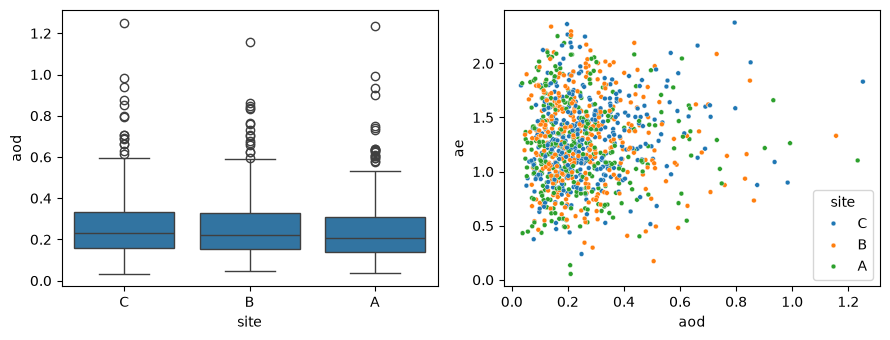

In [71]:
# `df` still exists - same shell as the previous call
r = run("demo", """
fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))
sns.boxplot(data=df, x="site", y="aod", ax=ax[0])
sns.scatterplot(data=df, x="aod", y="ae", hue="site", s=12, ax=ax[1])
fig.tight_layout()
df.to_parquet("/workspace/random_demo.parquet")
""")

In [72]:
state("demo")

{'vars': {'rng': 'Generator',
  'df': 'DataFrame(1000, 3)',
  'fig': 'Figure',
  'ax': 'ndarray(2,)'},
 'files': ['fig_001.png', 'fig_002.png', 'random_demo.parquet'],
 'workspace_mb': 0,
 'workspace_cap_mb': 1000,
 'rss_mb': 168}

[result]
DataFrame (8234, 4)
dtypes:
AERONET_Site_Name              string[python]
date                           datetime64[ns]
AOD_500nm                             float64
Angstrom_Exponent_440_870nm           float64

head:
  AERONET_Site_Name       date  AOD_500nm  Angstrom_Exponent_440_870nm
0              GSFC 1993-05-14        NaN                     1.052498
1              GSFC 1993-05-15        NaN                     1.094614
2              GSFC 1993-05-26        NaN                     1.372727
3              GSFC 1993-05-27        NaN                     1.080505
4              GSFC 1993-06-16        NaN                     1.211340

tail:
     AERONET_Site_Name       date  AOD_500nm  Angstrom_Exponent_440_870nm
8229              GSFC 2026-01-01   0.029878                     1.131348
8230              GSFC 2026-01-02   0.115354                     1.510442
8231              GSFC 2026-01-04   0.072467                     1.709800
8232              GSFC 2026-01-07   0.11292

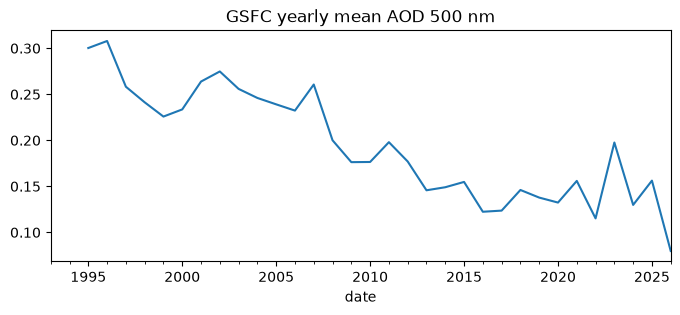

In [73]:
# the real AERONET table over the read-only mount (read a column subset - the whole table is ~1 GB in pandas)
r = run("demo", """
cols = ["AERONET_Site_Name", "date", "AOD_500nm", "Angstrom_Exponent_440_870nm"]
gsfc = pd.read_parquet(DATA, columns=cols, filters=[("AERONET_Site_Name", "==", "GSFC")])
monthly = gsfc.set_index("date")["AOD_500nm"].resample("YE").mean()
monthly.plot(title="GSFC yearly mean AOD 500 nm", figsize=(8, 3))
gsfc
""")

In [74]:
state("demo")

{'vars': {'rng': 'Generator',
  'df': 'DataFrame(1000, 3)',
  'fig': 'Figure',
  'ax': 'ndarray(2,)',
  'cols': 'list',
  'gsfc': 'DataFrame(8234, 4)',
  'monthly': 'Series(34,)'},
 'files': ['fig_001.png', 'fig_002.png', 'random_demo.parquet'],
 'workspace_mb': 0,
 'workspace_cap_mb': 1000,
 'rss_mb': 254}

In [75]:
sorted(p.name for p in (CONV_DIR / "demo").iterdir())   # the same files, seen from the host

['exec.sock', 'fig_001.png', 'fig_002.png', 'random_demo.parquet']

This way, we can run code inside the isolated container, preview a variable clipped by its first 5 lines and last 5 lines with string (prints and errors clipped to first 4000 characters), see state (which variables are active, their dtype and shape, and files in the directory)

## 6 · Isolation checks

In [76]:
r = run("demo", "open('/data/aeronet.parquet', 'ab').write(b'x')")     # data is read-only

[stdout]
---------------------------------------------------------------------------
OSError                                   Traceback (most recent call last)
Cell In[4], line 1
----> 1 open('/data/aeronet.parquet', 'ab').write(b'x')

OSError: [Errno 30] Read-only file system: '/data/aeronet.parquet'

[error]
OSError(30, 'Read-only file system')
ok=False  elapsed=0.167s  rss=265MB


In [77]:
r = run("demo", "open('/etc/hacked', 'w')")                             # root fs is read-only

[stdout]
---------------------------------------------------------------------------
OSError                                   Traceback (most recent call last)
Cell In[5], line 1
----> 1 open('/etc/hacked', 'w')

OSError: [Errno 30] Read-only file system: '/etc/hacked'

[error]
OSError(30, 'Read-only file system')
ok=False  elapsed=0.007s  rss=265MB


In [78]:
r = run("demo", "import urllib.request; urllib.request.urlopen('https://aeronet.gsfc.nasa.gov', timeout=5)")   # no network

[stdout]
---------------------------------------------------------------------------
gaierror                                  Traceback (most recent call last)
File /usr/local/lib/python3.13/urllib/request.py:1318, in AbstractHTTPHandler.do_open(self, http_class, req, **http_conn_args)
   1317 try:
-> 1318     h.request(req.get_method(), req.selector, req.data, headers,
   1319               encode_chunked=req.has_header('Transfer-encoding'))
   1320 except OSError as err: # timeout error

File /usr/local/lib/python3.13/http/client.py:1386, in HTTPConnection.request(self, method, url, body, headers, encode_chunked)
   1385 """Send a complete request to the server."""
-> 1386 self._send_request(method, url, body, headers, encode_chunked)

File /usr/local/lib/python3.13/http/client.py:1432, in HTTPConnection._send_request(self, method, url, body, headers, encode_chunked)
   1431     body = _encode(body, 'body')
-> 1432 self.endheaders(body, encode_chunked=encode_chunked)

File /usr/loca

In [79]:
r = run("demo", "import time; time.sleep(30)", timeout=3)                 # timeout -> cell interrupted, shell survives

[stdout]
---------------------------------------------------------------------------
TimeoutError                              Traceback (most recent call last)
Cell In[7], line 1
----> 1 import time; time.sleep(30)

File /exec_server.py:106, in _timeout(signum, frame)
    105 def _timeout(signum, frame):
--> 106     raise TimeoutError("cell exceeded its timeout")

TimeoutError: cell exceeded its timeout

[error]
TimeoutError('cell exceeded its timeout')
[vars_new] {'time': 'module'}
ok=False  elapsed=3.023s  rss=277MB


In [81]:
r

{'ok': False,
 'timed_out': True,
 'error': "TimeoutError('cell exceeded its timeout')",
 'stdout': '---------------------------------------------------------------------------\nTimeoutError                              Traceback (most recent call last)\nCell In[7], line 1\n----> 1 import time; time.sleep(30)\n\nFile /exec_server.py:106, in _timeout(signum, frame)\n    105 def _timeout(signum, frame):\n--> 106     raise TimeoutError("cell exceeded its timeout")\n\nTimeoutError: cell exceeded its timeout\n',
 'stderr': '',
 'result': None,
 'figures': [],
 'new_files': [],
 'vars_new': {'time': 'module'},
 'vars_changed': {},
 'elapsed_s': 3.023,
 'rss_mb': 277}

In [80]:
state("demo")

{'vars': {'rng': 'Generator',
  'df': 'DataFrame(1000, 3)',
  'fig': 'Figure',
  'ax': 'ndarray(2,)',
  'cols': 'list',
  'gsfc': 'DataFrame(8234, 4)',
  'monthly': 'Series(34,)',
  'urllib': 'module',
  'time': 'module'},
 'files': ['fig_001.png', 'fig_002.png', 'random_demo.parquet'],
 'workspace_mb': 0,
 'workspace_cap_mb': 1000,
 'rss_mb': 277}

In [82]:
r = run("demo", "big = np.ones(3_000_000_000, dtype=np.uint8)")         # 3 GB > 2 GB limit -> container is killed and removed
r = run("demo", "1 + 1")                                                   # the next call explains what happened

[error]
sandbox 'demo' is not running: killed by the memory limit. All variables are lost, files are kept. start('demo') gives a fresh sandbox.
ok=False  elapsed=Nones  rss=NoneMB
[error]
sandbox 'demo' is not running: killed by the memory limit. All variables are lost, files are kept. start('demo') gives a fresh sandbox.
ok=False  elapsed=Nones  rss=NoneMB


In [83]:
start("demo")                     # fresh container on the same folder
state("demo")                     # files are still there, variables are gone

{'vars': {},
 'files': ['fig_001.png', 'fig_002.png', 'random_demo.parquet'],
 'workspace_mb': 0,
 'workspace_cap_mb': 1000,
 'rss_mb': 151}

In [84]:
start("disk_test", workspace_gb=0.05)                                     # 50 MB cap for the demo
r = run("disk_test", "np.zeros(30_000_000, dtype=np.uint8).tofile('/workspace/a.bin')")   # 30 MB: fine
r = run("disk_test", "np.zeros(100_000_000, dtype=np.uint8).tofile('/workspace/c.bin')")  # kernel stops the file at 50 MB, watchdog kills the container
r = run("disk_test", "1 + 1")                                                             # ... and the reason
start("disk_test", workspace_gb=0.05)
state("disk_test")                                                                        # c.bin deleted, a.bin kept
stop("disk_test")

ok=True  elapsed=0.021s  rss=151MB
[stdout]
---------------------------------------------------------------------------
OSError                                   Traceback (most recent call last)
Cell In[2], line 1
----> 1 np.zeros(100_000_000, dtype=np.uint8).tofile('/workspace/c.bin')

OSError: 100000000 requested and 50000000 written

[error]
OSError('100000000 requested and 50000000 written')
ok=False  elapsed=0.094s  rss=152MB
[result]
2
ok=True  elapsed=0.003s  rss=152MB


In [85]:
start("other")
r = run("other", "print(df)")      # `df` of "demo" does not exist here
stop("other")

[stdout]
---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
Cell In[1], line 1
----> 1 print(df)

NameError: name 'df' is not defined

[error]
NameError("name 'df' is not defined")
ok=False  elapsed=0.063s  rss=152MB


In [86]:
reset("demo")
state("demo")

{'vars': {},
 'files': ['fig_001.png', 'fig_002.png', 'random_demo.parquet'],
 'workspace_mb': 0,
 'workspace_cap_mb': 1000,
 'rss_mb': 151}

## 7 · Idle stop

60 min by default; 6 s here so we can watch it happen.

In [87]:
start("idle_test", idle_minutes=0.1)
time.sleep(15)
!docker ps --filter name=idle_test
!docker ps --filter name=demo

CONTAINER ID   IMAGE     COMMAND   CREATED   STATUS    PORTS     NAMES
CONTAINER ID   IMAGE             COMMAND                  CREATED          STATUS          PORTS     NAMES
340a811c923a   aeronet-sandbox   "python /exec_server…"   52 seconds ago   Up 51 seconds             demo


In [88]:
!docker ps

CONTAINER ID   IMAGE                        COMMAND                  CREATED              STATUS                  PORTS                      NAMES
340a811c923a   aeronet-sandbox              "python /exec_server…"   About a minute ago   Up About a minute                                  demo
113457c029af   aaqe1-frontend               "/docker-entrypoint.…"   10 hours ago         Up 10 hours             127.0.0.1:8082->80/tcp     aqf_frontend1
7e8e57667fdb   aaqe1-backend                "docker-entrypoint.s…"   10 hours ago         Up 10 hours (healthy)   3001/tcp                   aqf_backend1
e73d4672d59b   air-quality-chatbot-web      "sh -c 'exec python …"   3 weeks ago          Up 2 weeks (healthy)    127.0.0.1:5000->8000/tcp   vayu
ac1ee02bc205   african_dashboard-frontend   "/docker-entrypoint.…"   3 weeks ago          Up 2 weeks              127.0.0.1:8080->80/tcp     aqf_frontend
9d943d9f8556   african_dashboard-backend    "docker-entrypoint.s…"   3 weeks ago          Up 2 wee

In [89]:
start("idle_test", idle_minutes=0.2)

{'python': '3.13.15',
 'packages': {'numpy': '2.2.2',
  'pandas': '2.2.3',
  'pyarrow': '24.0.0',
  'matplotlib': '3.11.2',
  'seaborn': '0.13.2',
  'ipython': '9.17.1'},
 'memory_limit_mb': 2147,
 'cpus': 2.0,
 'workspace_cap_gb': 1.0,
 'data': '/data/aeronet.parquet',
 'preloaded': 'import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns\nDATA = "/data/aeronet.parquet"   # AERONET AOD L2 daily table (read-only)'}

In [ ]:
!docker ps

CONTAINER ID   IMAGE                        COMMAND                  CREATED              STATUS                  PORTS                      NAMES
59f20d403c3b   aeronet-sandbox              "python /exec_server…"   5 seconds ago        Up 5 seconds                                       idle_test
340a811c923a   aeronet-sandbox              "python /exec_server…"   About a minute ago   Up About a minute                                  demo
113457c029af   aaqe1-frontend               "/docker-entrypoint.…"   10 hours ago         Up 10 hours             127.0.0.1:8082->80/tcp     aqf_frontend1
7e8e57667fdb   aaqe1-backend                "docker-entrypoint.s…"   10 hours ago         Up 10 hours (healthy)   3001/tcp                   aqf_backend1
e73d4672d59b   air-quality-chatbot-web      "sh -c 'exec python …"   3 weeks ago          Up 2 weeks (healthy)    127.0.0.1:5000->8000/tcp   vayu
ac1ee02bc205   african_dashboard-frontend   "/docker-entrypoint.…"   3 weeks ago          Up 2 weeks 

We see the idle_test container up and runnig.. now we wait for 20 seconds and re run the above command and see if its runnig or not

In [91]:
time.sleep(20)
!docker ps

CONTAINER ID   IMAGE                        COMMAND                  CREATED         STATUS                  PORTS                      NAMES
340a811c923a   aeronet-sandbox              "python /exec_server…"   2 minutes ago   Up 2 minutes                                       demo
113457c029af   aaqe1-frontend               "/docker-entrypoint.…"   10 hours ago    Up 10 hours             127.0.0.1:8082->80/tcp     aqf_frontend1
7e8e57667fdb   aaqe1-backend                "docker-entrypoint.s…"   10 hours ago    Up 10 hours (healthy)   3001/tcp                   aqf_backend1
e73d4672d59b   air-quality-chatbot-web      "sh -c 'exec python …"   3 weeks ago     Up 2 weeks (healthy)    127.0.0.1:5000->8000/tcp   vayu
ac1ee02bc205   african_dashboard-frontend   "/docker-entrypoint.…"   3 weeks ago     Up 2 weeks              127.0.0.1:8080->80/tcp     aqf_frontend
9d943d9f8556   african_dashboard-backend    "docker-entrypoint.s…"   3 weeks ago     Up 2 weeks (healthy)    3001/tcp           

As we can see, idle_test is long gone!!

## 8 · Cleanup

In [92]:
stop("demo")
!docker ps --filter name=demo

CONTAINER ID   IMAGE     COMMAND   CREATED   STATUS    PORTS     NAMES


## This way, we now have a lightweight endpoint that can run code, state variables, reset environment, list the env.. so our agent will use this to do analytics